In [176]:
import os
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [177]:
INPUT = 'data/news_vnexpress'

In [178]:
print('Các nhãn và số văn bản tương ứng trong dữ liệu')
print('----------------------------------------------')
n = 0
for label in os.listdir(INPUT):
    # Khong doc file .DS_Store
    if label.startswith('.'): continue
    label_path = os.path.join(INPUT,label)
    num = 0
    for file_name in os.listdir(label_path):
        #Khong doc file .DS_Store
        if file_name.startswith('.'): continue
        num += 1
    n += num
    print(label, ':',num)
    
print('-------------------------')
print('Tổng số văn bản: ',n)


Các nhãn và số văn bản tương ứng trong dữ liệu
----------------------------------------------
doi-song : 120
du-lich : 54
phap-luat : 59
the-thao : 173
thoi-su : 59
suc-khoe : 162
giai-tri : 201
giao-duc : 105
kinh-doanh : 262
khoa-hoc : 144
-------------------------
Tổng số văn bản:  1339


In [179]:
news = load_files(INPUT,encoding='utf-8')
data_set = news.data
target = news.target

In [180]:
print('mapping:')
mapping = {}
for i in range(len(news.target_names)):
    mapping[i] = news.target_names[i]
    print(news.target_names[i],'-',i)
print('--------------------------')
print(news.filenames[0:1])
print(news.target[0:1])
print('Tổng số  văn bản:',len(data_set))

mapping:
doi-song - 0
du-lich - 1
giai-tri - 2
giao-duc - 3
khoa-hoc - 4
kinh-doanh - 5
phap-luat - 6
suc-khoe - 7
the-thao - 8
thoi-su - 9
--------------------------
['data/news_vnexpress/khoa-hoc/00133.txt']
[4]
Tổng số  văn bản: 1339


In [181]:
with open('data/vietnamese-stopwords.txt',encoding='utf-8') as f:
    stopwords = f.readlines()
def tokenize_vn(text):
    return ViTokenizer.tokenize(text).split()
for i in range(len(stopwords)):
    stopwords[i] = stopwords[i].strip().replace(' ','_')
bow = CountVectorizer(stop_words=stopwords,
    tokenizer=tokenize_vn, token_pattern=None)
tf = Pipeline(steps=[
    ('vec',bow),
    ('idf',TfidfTransformer())
])
data_preprocessed = tf.fit_transform(data_set)

In [182]:
print('Số lượng stopwords:', len(stopwords))
print(stopwords[:10])
print('Số lượng từ trong từ điển:',len(bow.vocabulary_))
print('Kích thước dữ liệu sau khi xử lý:',data_preprocessed.shape)
print('Kích thước nhãn tương ứng:',target.shape)

Số lượng stopwords: 2063
['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']
Số lượng từ trong từ điển: 22537
Kích thước dữ liệu sau khi xử lý: (1339, 22537)
Kích thước nhãn tương ứng: (1339,)


### Chia dữ liệu thành tập train và test
Code mẫu sử dụng pivot khá khó hiểu, nhưng nếu muốn dùng thư viện và tránh việc xáo trộn có thể dùng shuffle = False

In [183]:
X_train ,X_test, y_train, y_test = train_test_split(data_preprocessed,target,shuffle=False,test_size=0.2)

# 3. Lựa chọn (tối ưu) tham số

Chỉ dùng tập train để thực hiện lựa chọn tham số. 
- SVM: kernel, C
- Random Forest: criteria, N

Ta sẽ dùng chiến lược Cross Validation trong bước này.

## 3.1. Đánh giá hiệu quả của các kernel trong SVM

In [184]:
gs = GridSearchCV(estimator=SVC(C=1),param_grid={
    'kernel':['linear', 'poly', 'rbf', 'sigmoid']
}, cv=10,n_jobs=-1,scoring='accuracy')
gs.fit(X_train,y_train)

,estimator,SVC(C=1)
,param_grid,"{'kernel': ['linear', 'poly', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [185]:
gs.cv_results_

{'mean_fit_time': array([1.18193645, 1.55593402, 1.56506076, 1.01072624]),
 'std_fit_time': array([0.02631445, 0.03228364, 0.01267931, 0.02567373]),
 'mean_score_time': array([0.09639859, 0.09032691, 0.08988333, 0.05990956]),
 'std_score_time': array([0.01523003, 0.00505743, 0.00573042, 0.00758062]),
 'param_kernel': masked_array(data=['linear', 'poly', 'rbf', 'sigmoid'],
              mask=[False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'kernel': 'linear'},
  {'kernel': 'poly'},
  {'kernel': 'rbf'},
  {'kernel': 'sigmoid'}],
 'split0_test_score': array([0.93518519, 0.63888889, 0.88888889, 0.94444444]),
 'split1_test_score': array([0.91588785, 0.57943925, 0.8411215 , 0.90654206]),
 'split2_test_score': array([0.95327103, 0.65420561, 0.87850467, 0.94392523]),
 'split3_test_score': array([0.91588785, 0.63551402, 0.88785047, 0.93457944]),
 'split4_test_score': array([0.88785047, 0.65420561, 0.8411215 , 0.90654206]),
 'split5_test_sco

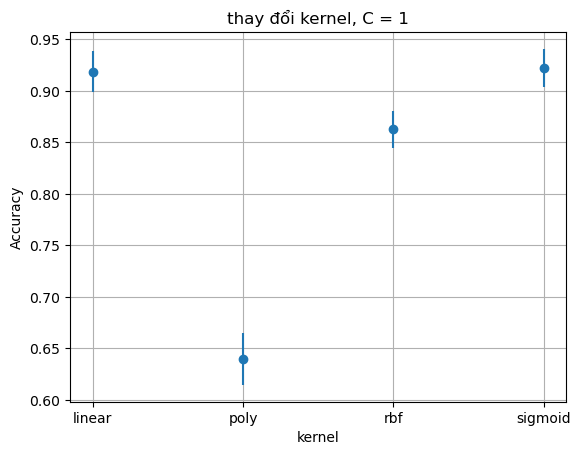

In [186]:
mean_score = gs.cv_results_['mean_test_score']
std_score = gs.cv_results_['std_test_score']
plt.errorbar(x=['linear', 'poly', 'rbf', 'sigmoid'],y=mean_score,
    yerr=std_score,linestyle='None', marker='o')
plt.grid()
plt.xlabel('kernel')
plt.ylabel('Accuracy')
plt.title('thay đổi kernel, C = 1')
plt.show()

## 3.2. Đánh giá ảnh hưởng của tham số C trong SVM

In [187]:
gs = GridSearchCV(estimator=SVC(kernel='linear'),param_grid={
    'C':[.1, 1.0, 2.0, 5.0, 10.0]
}, scoring='accuracy',cv=10,n_jobs=-1)
gs.fit(X_train,y_train)

,estimator,SVC(kernel='linear')
,param_grid,"{'C': [0.1, 1.0, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,5.0


In [188]:
gs.cv_results_

{'mean_fit_time': array([1.29722502, 1.32719634, 1.32165368, 1.37458885, 1.31095974]),
 'std_fit_time': array([0.03606847, 0.04492773, 0.02108817, 0.05284128, 0.05160201]),
 'mean_score_time': array([0.08437874, 0.07118392, 0.07206073, 0.07360449, 0.05763297]),
 'std_score_time': array([0.00997095, 0.00586317, 0.00710972, 0.00577059, 0.00568487]),
 'param_C': masked_array(data=[0.1, 1.0, 2.0, 5.0, 10.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'C': 0.1}, {'C': 1.0}, {'C': 2.0}, {'C': 5.0}, {'C': 10.0}],
 'split0_test_score': array([0.37962963, 0.93518519, 0.96296296, 0.97222222, 0.97222222]),
 'split1_test_score': array([0.40186916, 0.91588785, 0.93457944, 0.93457944, 0.93457944]),
 'split2_test_score': array([0.39252336, 0.95327103, 0.94392523, 0.94392523, 0.94392523]),
 'split3_test_score': array([0.41121495, 0.91588785, 0.94392523, 0.94392523, 0.94392523]),
 'split4_test_score': array([0.42056075, 0.88785047, 0.89719626, 0.9065

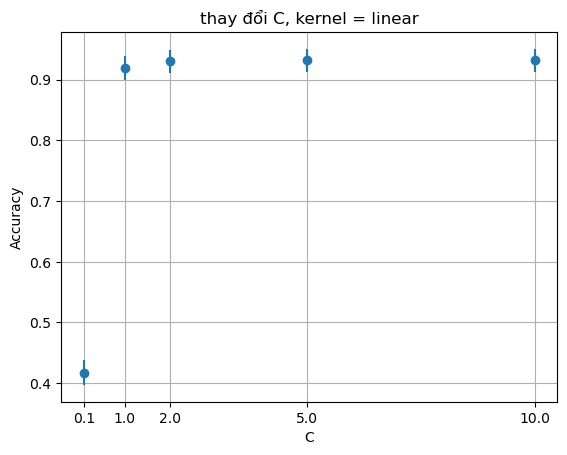

In [189]:
mean_score = gs.cv_results_['mean_test_score']
std_score = gs.cv_results_['std_test_score']
plt.errorbar(x = [.1, 1.0, 2.0, 5.0, 10.0], y = mean_score,
    yerr=std_score,linestyle = 'None', marker = 'o')
plt.grid()
plt.xlabel('C')
plt.xticks([.1, 1.0, 2.0, 5.0, 10.0])
plt.ylabel('Accuracy')
plt.title('thay đổi C, kernel = linear')
plt.show()

## 3.3. Đánh giá ảnh hưởng của độ đo trong Random Forest

In [190]:
gs = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),param_grid={
    'criterion':["gini", "entropy"]
}, scoring='accuracy',cv = 10, n_jobs=-1)
gs.fit(X_train,y_train)

,estimator,RandomForestC...estimators=50)
,param_grid,"{'criterion': ['gini', 'entropy']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


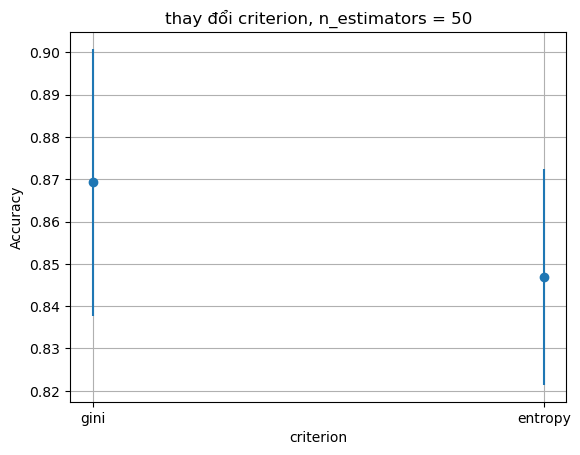

In [191]:
mean_score = gs.cv_results_['mean_test_score']
std_score = gs.cv_results_['std_test_score']
plt.errorbar(x=["gini", "entropy"],y=mean_score,yerr=std_score
    ,linestyle = 'None',marker = 'o')
plt.grid()
plt.xlabel('criterion')
plt.ylabel('Accuracy')
plt.title('thay đổi criterion, n_estimators = 50')
plt.show()

## 3.4. Đánh giá ảnh hưởng của số cây trong Random Forest 

In [192]:
gs = GridSearchCV(estimator=RandomForestClassifier(criterion='gini'),param_grid={
    'n_estimators':[10,50,100,300]
}, scoring='accuracy',cv = 10, n_jobs=-1)
gs.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'n_estimators': [10, 50, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


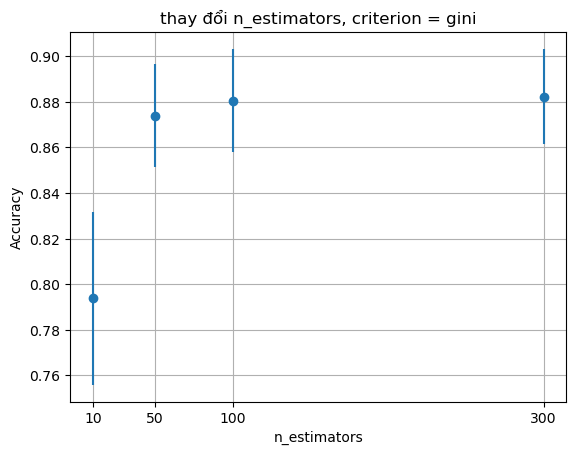

In [193]:
mean_score = gs.cv_results_['mean_test_score']
std_score = gs.cv_results_['std_test_score']
plt.errorbar(x=[10,50,100,300],y=mean_score,yerr=std_score
    ,linestyle = 'None',marker = 'o')
plt.grid()
plt.xlabel('n_estimators')
plt.xticks([10,50,100,300])
plt.ylabel('Accuracy')
plt.title('thay đổi n_estimators, criterion = gini')
plt.show()

# 4. So sánh các mô hình
- Sau khi chọn được các bộ tham số tốt nhất cho mỗi mô hình, ta huấn luyện lại trên toàn bộ tập Train.
- Dùng các mô hình mới huấn luyện để phán đoán cho các dữ liệu trong tập Test
- Đo đạc Độ chính xác (Accuracy) của chúng và so sánh kết quả.

In [194]:
svm = SVC(kernel='linear', C=1.0)
rf = RandomForestClassifier(criterion='gini',n_estimators=100)
svm.fit(X_train,y_train)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [195]:
print('SVM',accuracy_score(y_test,svm.predict(X_test)))
print('RF',accuracy_score(y_test,rf.predict(X_test)))

SVM 0.917910447761194
RF 0.8544776119402985


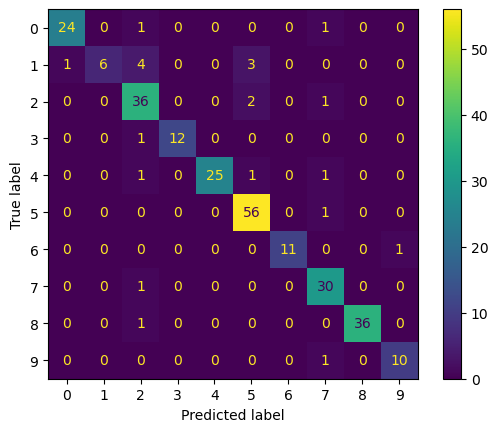

In [196]:
cm = confusion_matrix(y_test,svm.predict(X_test))
ConfusionMatrixDisplay(cm).plot()

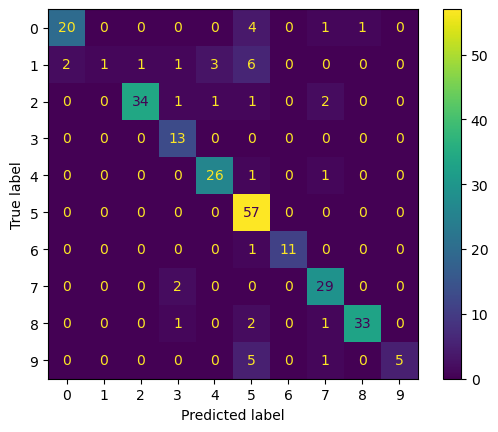

In [197]:
cm = confusion_matrix(y_test,rf.predict(X_test))
ConfusionMatrixDisplay(cm).plot()